# Time Series Introduction
So far we've been looking at "cross-sectional" data. This means we're looking at a set of units, $i$, at a single point in time $t=1$. 

This means we haven't been modelling anything to do with dynamics (usually quite an important consideration). 

This is where time series analysis comes in ...

In [1]:
%reset -f

In [2]:
import numpy             as np
import statsmodels.api   as sm
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from statsmodels.iolib.summary2 import summary_col

## set up seaborn parameters for plotting

In [3]:
pd.plotting.register_matplotlib_converters()
# Default figure size
sns.mpl.rc('figure',figsize=(16, 6))

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/Michael-Morgan-Giles/python-causality-handbook/refs/heads/master/causal-inference-for-the-brave-and-true/data/smoking.csv")

# filter for california
df = df[df['california'] == True]

# add binary variable for excise tax intro
df['excise_tax_intro'] = np.where(df['after_treatment'] == True,1,0)

df = df[['year', 'cigsale','retprice','excise_tax_intro']]

# create log variables for elasticity estimates:
for x in ['cigsale','retprice']:
    df[f"ln_{x}"] = np.log(df[x])

# print info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 62 to 92
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              31 non-null     int64  
 1   cigsale           31 non-null     float64
 2   retprice          31 non-null     float64
 3   excise_tax_intro  31 non-null     int64  
 4   ln_cigsale        31 non-null     float64
 5   ln_retprice       31 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 1.7 KB


In [5]:
df.describe()

,year,cigsale,retprice,excise_tax_intro,ln_cigsale,ln_retprice
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,1985.000000,94.587097,119.922582,0.387097,4.491559,4.579469
std,9.092121,30.007130,77.903847,0.495138,0.361709,0.663963
min,1970.000000,41.599998,38.799999,0.000000,3.728100,3.658420
25%,1977.500000,65.450001,53.850000,0.000000,4.180796,3.982130
50%,1985.000000,102.800003,98.000000,0.000000,4.632785,4.584967
75%,1992.500000,122.450001,192.700005,1.000000,4.807693,5.261057
max,2000.000000,128.000000,351.200012,1.000000,4.852030,5.861356


In [6]:
df.shape

(31, 6)

# autocorrelation analysis



In [7]:
from statsmodels.tsa.stattools     import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## set time index

## compute the ac and pac

In [8]:
print("the acf of cigsale", acf(df['cigsale']))
print()
print("the pacf of cigsale", pacf(df['cigsale']))

the acf of cigsale [ 1.          0.92463387  0.85041326  0.77206505  0.68548923  0.58812266
  0.48339924  0.37270124  0.26491293  0.15816898  0.05042692 -0.04410309
 -0.13425995 -0.21090169 -0.27078643]

the pacf of cigsale [ 1.          0.955455   -0.04399027 -0.11456301 -0.18321909 -0.24768913
 -0.24632239 -0.27589959 -0.18197654 -0.22497104 -0.34677905 -0.18401685
 -0.40472472 -0.40862803 -0.45129991]


## plot the ac and pac

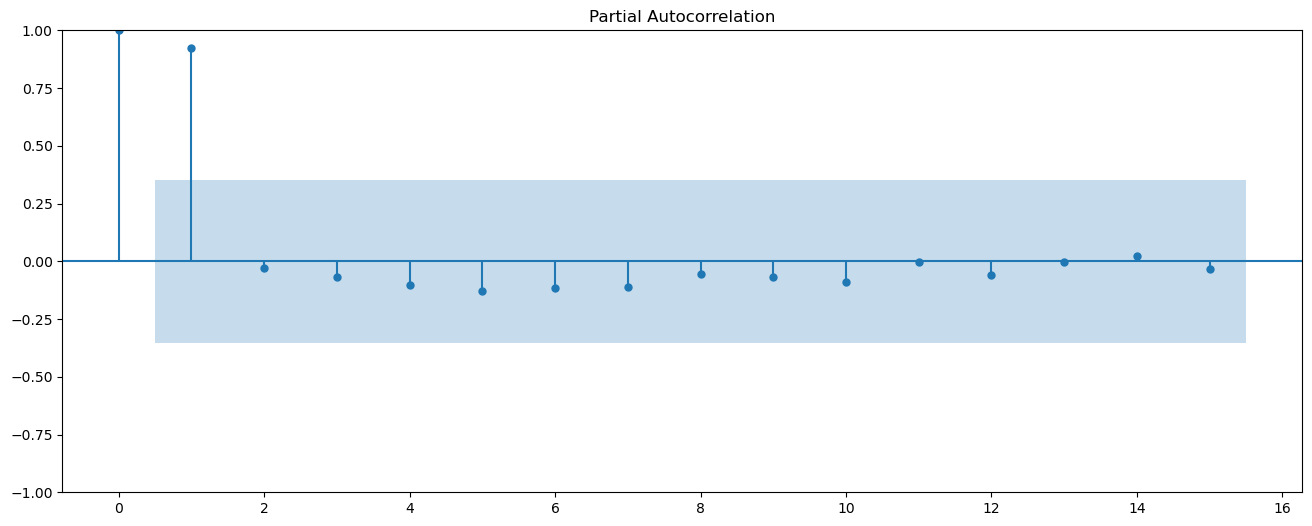

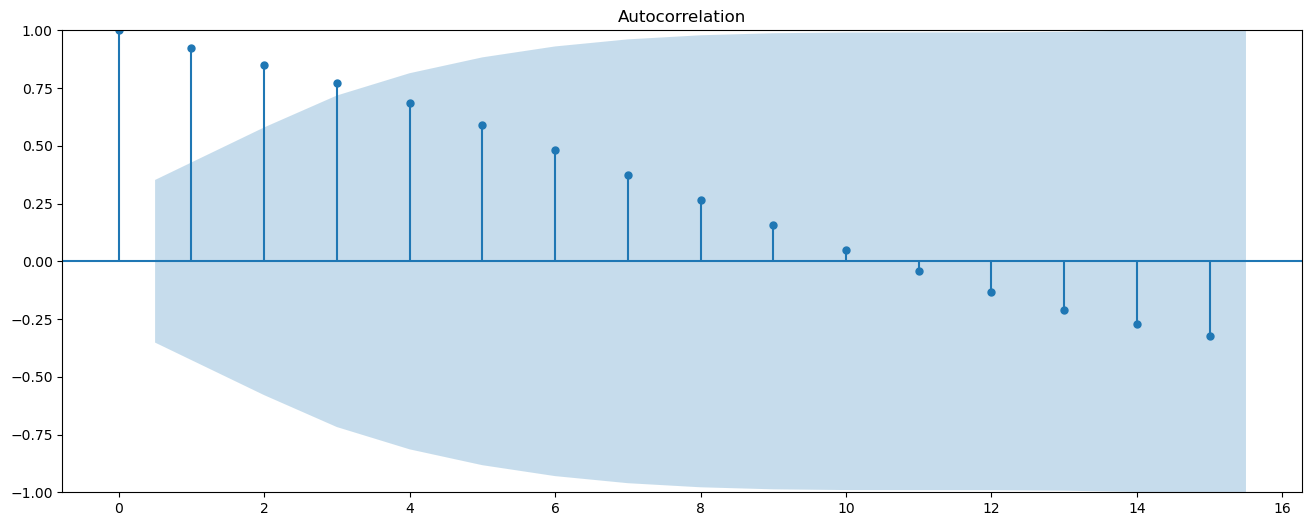

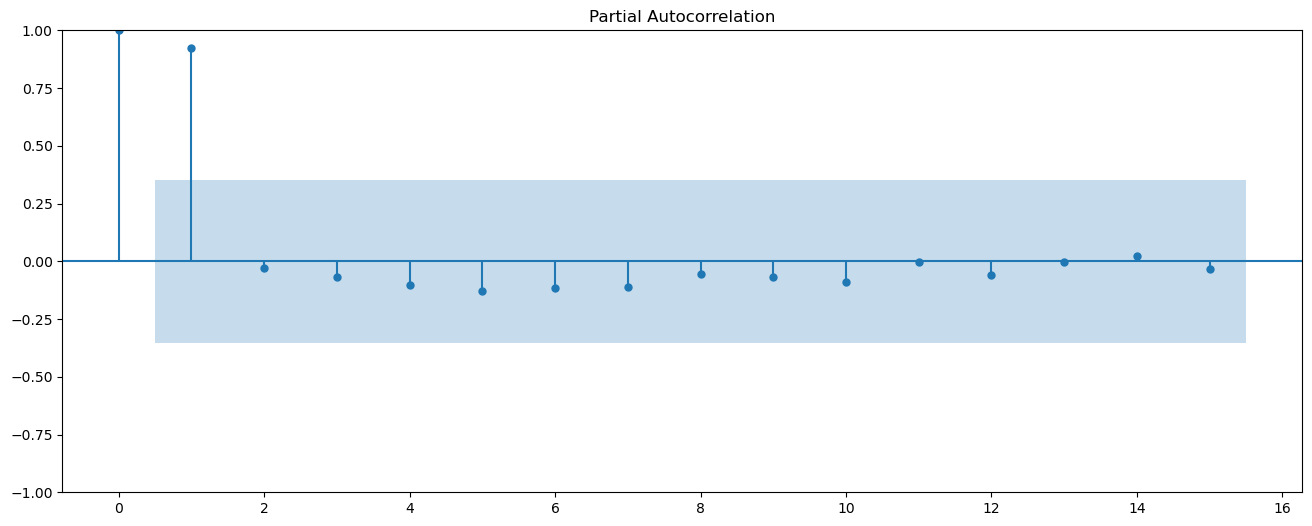

In [9]:
plot_acf(df['cigsale'], lags=15)
plot_pacf(df['cigsale'], lags=15)

## adf test

In [10]:
X = df['cigsale'].values
result1=adfuller(X,regression='ct',autolag='BIC',regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result1[0], result1[1], result1[2]))

 ADF statistic: -2.668, 
 p-value: 0.250, 
 critical value: {'1%': -4.2970953703703705, '5%': -3.5685571851851847, '10%': -3.2184266666666668}


# (h)

In [11]:
df['cigsale_D1'] = df['cigsale'].diff()

<AxesSubplot: >

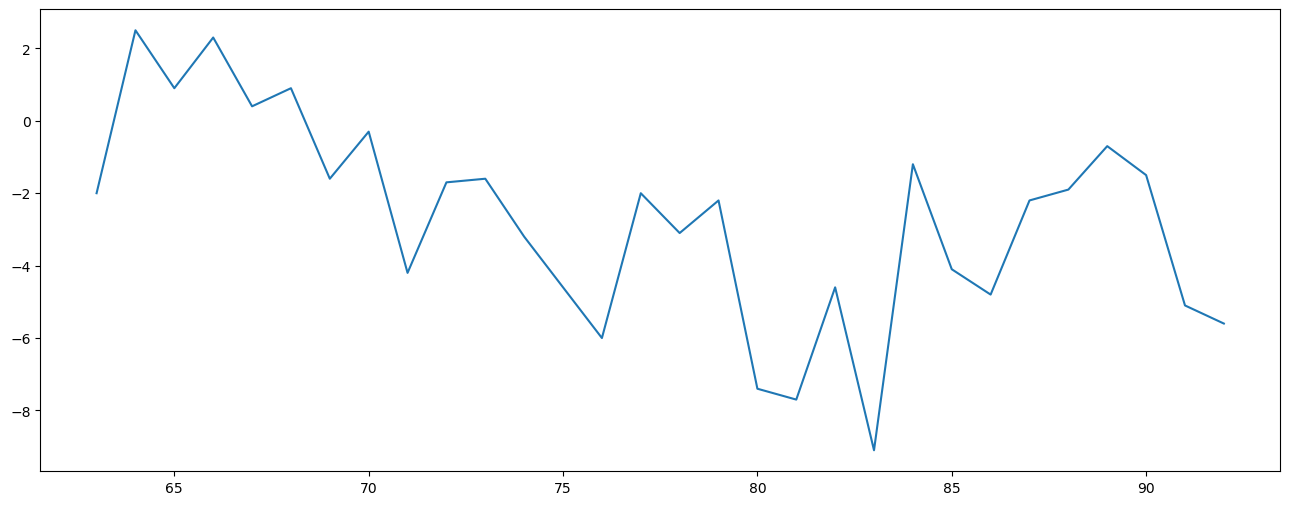

In [12]:
df['cigsale_D1'].plot()

# (a) 
Plotting the point at which observation the variable $\mathrm{excise_tax_intro}$ turns from $0$ to $1$. 

This shows which year the data the excise tax came into effect.

<AxesSubplot: xlabel='year', ylabel='excise_tax_intro'>

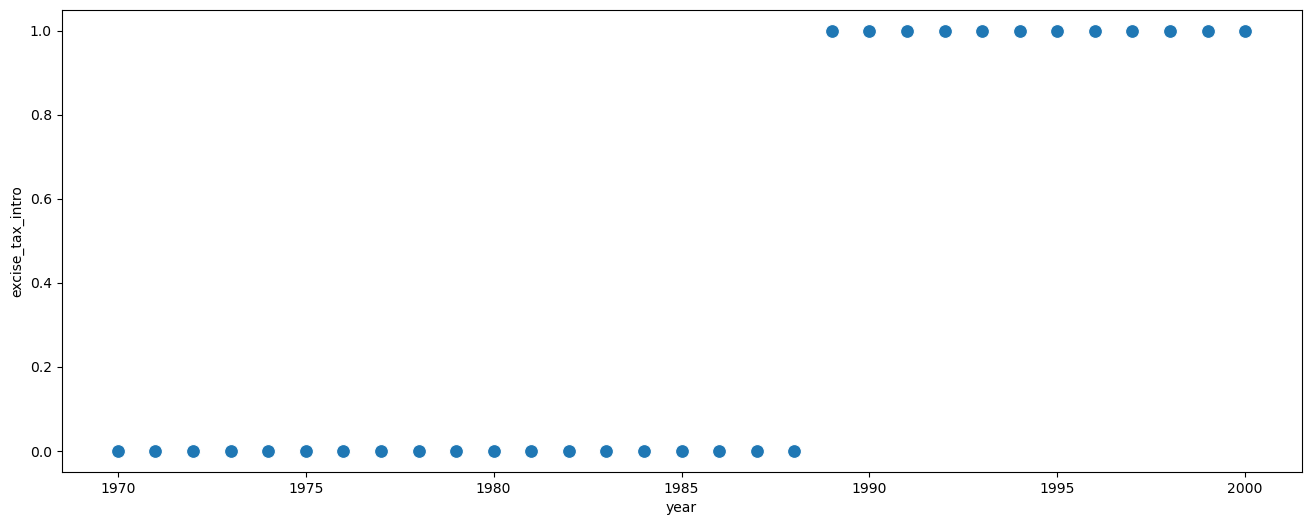

In [13]:
sns.scatterplot(y = 'excise_tax_intro',
            x = 'year', 
            data = df, 
               s = 100)

At this point what was the sales of cigs per capita ... 

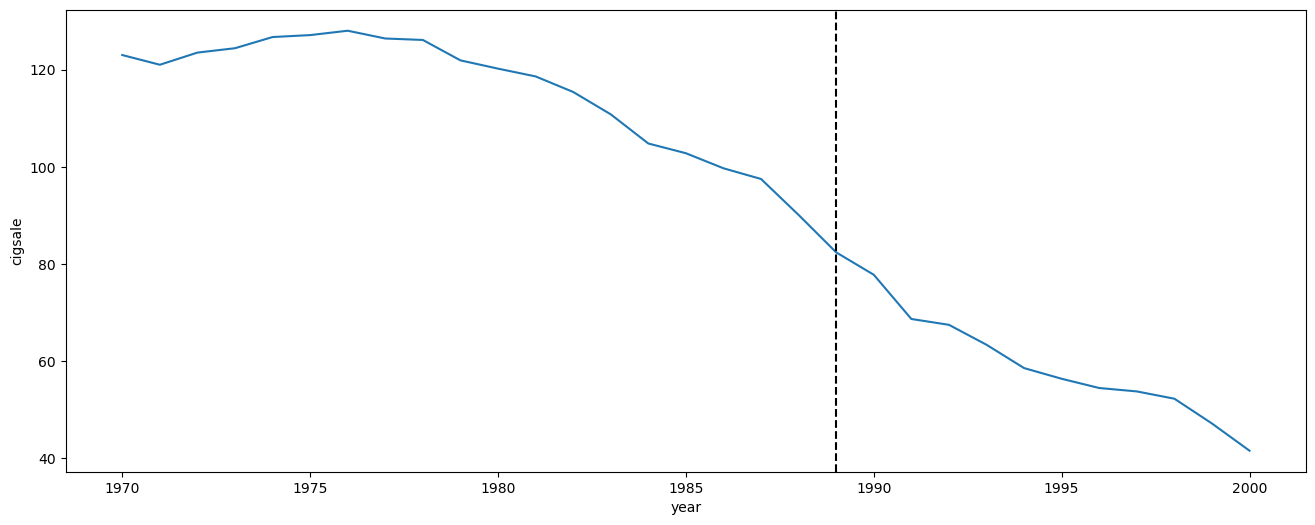

In [14]:
sns.lineplot(y = 'cigsale',
            x = 'year', 
            data = df)
plt.axvline(x = 1989, color = "black", linestyle = "--")

Modelling just on the excise tax introduction ...

In [15]:
print(sm.OLS(df['cigsale'], sm.add_constant(df[['excise_tax_intro', "retprice"]])).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                cigsale   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     266.3
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           6.03e-19
Time:                        17:22:08   Log-Likelihood:                -102.48
No. Observations:                  31   AIC:                             211.0
Df Residuals:                      28   BIC:                             215.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              133.0076      2.747  

In [16]:
print(sm.OLS(df['cigsale'], sm.add_constant(df[['excise_tax_intro', "ln_retprice"]])).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                cigsale   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     363.0
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           9.50e-21
Time:                        17:22:08   Log-Likelihood:                -97.880
No. Observations:                  31   AIC:                             201.8
Df Residuals:                      28   BIC:                             206.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              243.0446     13.794  

In [17]:
df['simple_mod_pred'] = sm.OLS(df['cigsale'], 
                               sm.add_constant(df[['excise_tax_intro',
                                                   "ln_retprice"]])).fit().predict()

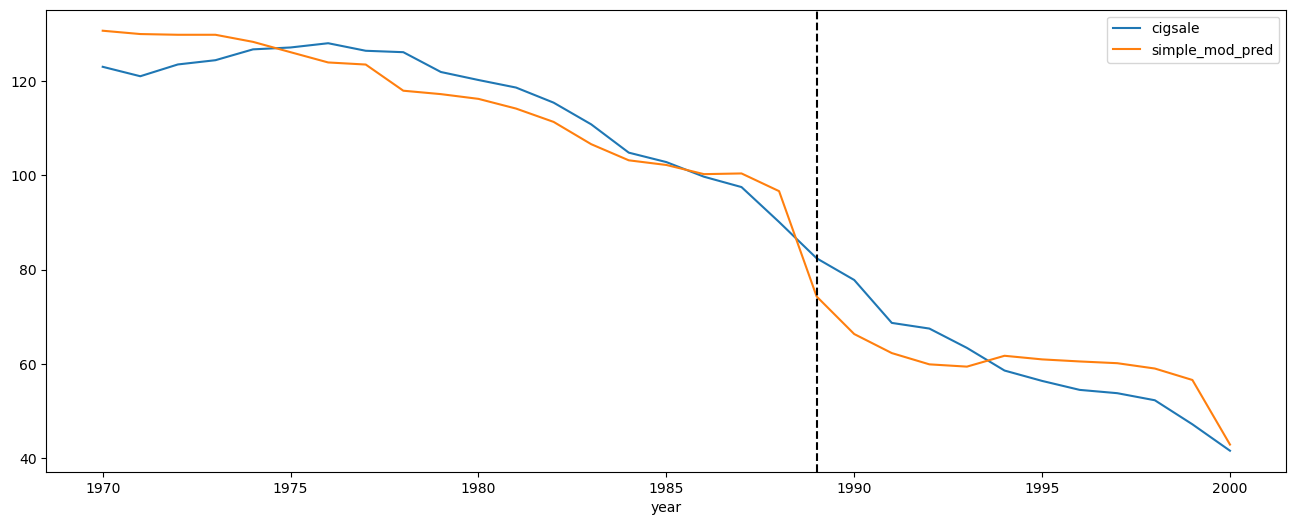

In [18]:
df.set_index("year")[['cigsale','simple_mod_pred']].plot()
plt.axvline(x = 1989, color = "black", linestyle = "--")

<AxesSubplot: xlabel='cigsale', ylabel='simple_mod_pred'>

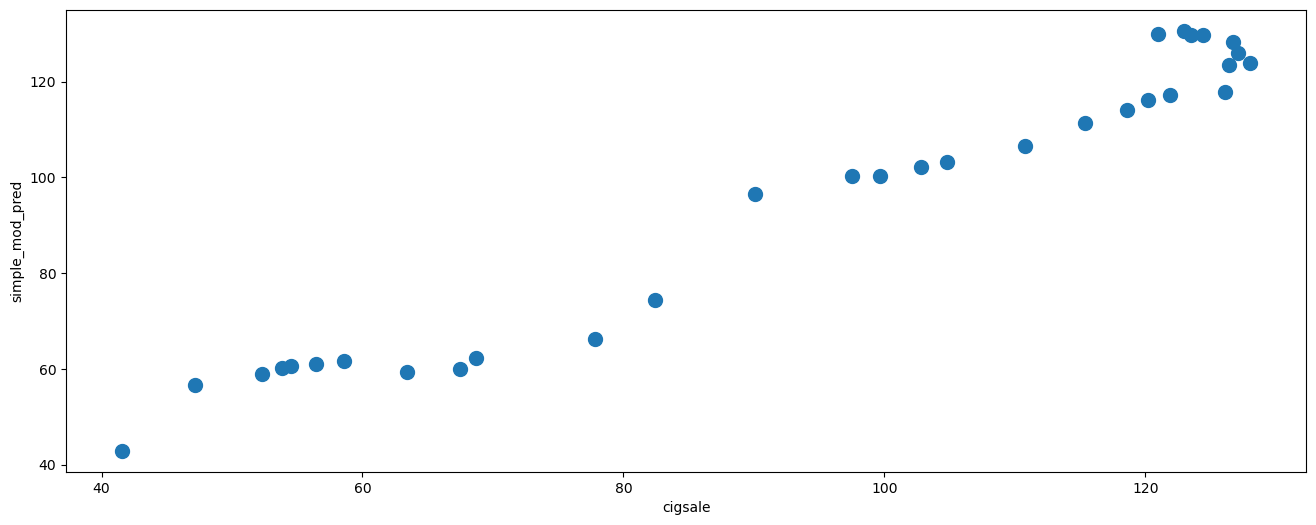

In [19]:
df.plot.scatter(x = 'cigsale', y = 'simple_mod_pred', s=100)

This simple model shows a really big decrease in cigeratte consumption per capita, but is this a causal effect? 




How about when we account for specific years ... 

In [20]:
df =  pd.concat([df,pd.get_dummies(df['year']).astype(int)], axis = 1)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 62 to 92
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              31 non-null     int64  
 1   cigsale           31 non-null     float64
 2   retprice          31 non-null     float64
 3   excise_tax_intro  31 non-null     int64  
 4   ln_cigsale        31 non-null     float64
 5   ln_retprice       31 non-null     float64
 6   cigsale_D1        30 non-null     float64
 7   simple_mod_pred   31 non-null     float64
 8   1970              31 non-null     int64  
 9   1971              31 non-null     int64  
 10  1972              31 non-null     int64  
 11  1973              31 non-null     int64  
 12  1974              31 non-null     int64  
 13  1975              31 non-null     int64  
 14  1976              31 non-null     int64  
 15  1977              31 non-null     int64  
 16  1978              31 non-null     int64  
 17  197

In [21]:
print(sm.OLS(df['cigsale'], 
             sm.add_constant(df[['excise_tax_intro', "ln_retprice"] + df.columns[25:40].tolist()])).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                cigsale   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     93.82
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           4.65e-12
Time:                        17:22:08   Log-Likelihood:                -78.367
No. Observations:                  31   AIC:                             188.7
Df Residuals:                      15   BIC:                             211.7
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              212.9869     12.877  

Wow after adding dummies for each year, it looks like the effect has actually increased!!! Wild.



In [22]:
df['complex_mod_pred'] =  sm.OLS(df['cigsale'], sm.add_constant(df[['excise_tax_intro', "ln_retprice"] + df.columns[25:40].tolist()])).fit().predict()

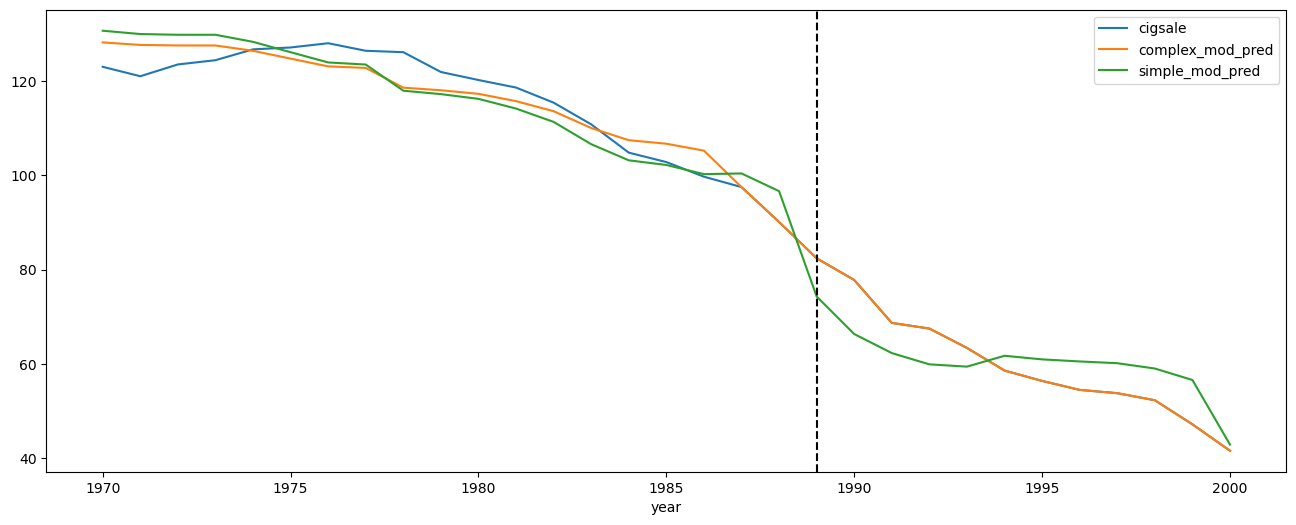

In [23]:
df.set_index("year")[['cigsale', 'complex_mod_pred','simple_mod_pred']].plot()
plt.axvline(x = 1989, color = "black", linestyle = "--")

<AxesSubplot: xlabel='cigsale', ylabel='complex_mod_pred'>

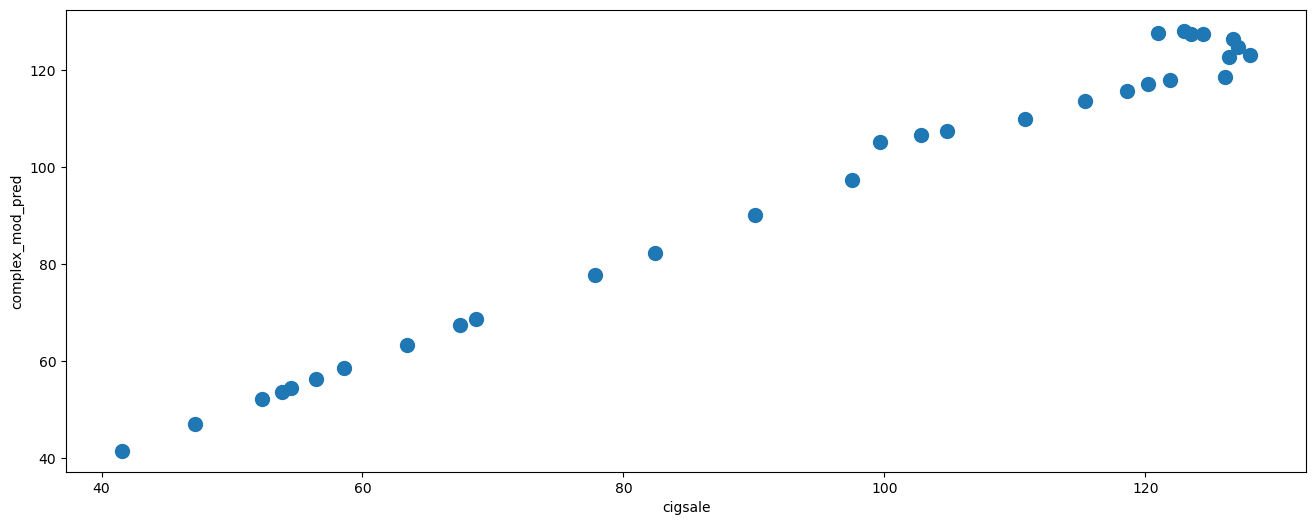

In [24]:
df.plot.scatter(x = 'cigsale', y = 'complex_mod_pred', s=100)

This model is overfit, especially if you lookt at the prediction for the post treatment intervention. It's a perfect fit!

This becomes a real problem if we try to generalise this effect to another scenario. For example, let's use this model to see what might happen in another state if they were to introduce a similar law - well the model probably won't perform very well. 


In [25]:
df_new = pd.read_csv("https://raw.githubusercontent.com/Michael-Morgan-Giles/python-causality-handbook/refs/heads/master/causal-inference-for-the-brave-and-true/data/smoking.csv")

# filter for not caligornita
df_new = df_new[df_new['state'] == 36]

# add binary variable for excise tax intro
df_new['excise_tax_intro'] = np.where(df_new['after_treatment'] == True,1,0)

df_new = df_new[['year', 'cigsale','retprice','excise_tax_intro']]

# create log variables for elasticity estimates:
for x in ['cigsale','retprice']:
    df_new[f"ln_{x}"] = np.log(df_new[x])

# dummies
df_new = pd.concat([df_new,pd.get_dummies(df_new['year']).astype(int)], axis = 1)

# print info
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 1085 to 1115
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              31 non-null     int64  
 1   cigsale           31 non-null     float64
 2   retprice          31 non-null     float64
 3   excise_tax_intro  31 non-null     int64  
 4   ln_cigsale        31 non-null     float64
 5   ln_retprice       31 non-null     float64
 6   1970              31 non-null     int64  
 7   1971              31 non-null     int64  
 8   1972              31 non-null     int64  
 9   1973              31 non-null     int64  
 10  1974              31 non-null     int64  
 11  1975              31 non-null     int64  
 12  1976              31 non-null     int64  
 13  1977              31 non-null     int64  
 14  1978              31 non-null     int64  
 15  1979              31 non-null     int64  
 16  1980              31 non-null     int64  
 17 

In [26]:
df_new['new_state_mod_pred'] =  sm.OLS(df['cigsale'], 
             sm.add_constant(df[['excise_tax_intro', 
                                 "ln_retprice"] + df.columns[26:38].tolist()])).fit().predict(sm.add_constant(df_new[['excise_tax_intro', 
                                                                                                                      "ln_retprice"] + df_new.columns[25:40].tolist()]))

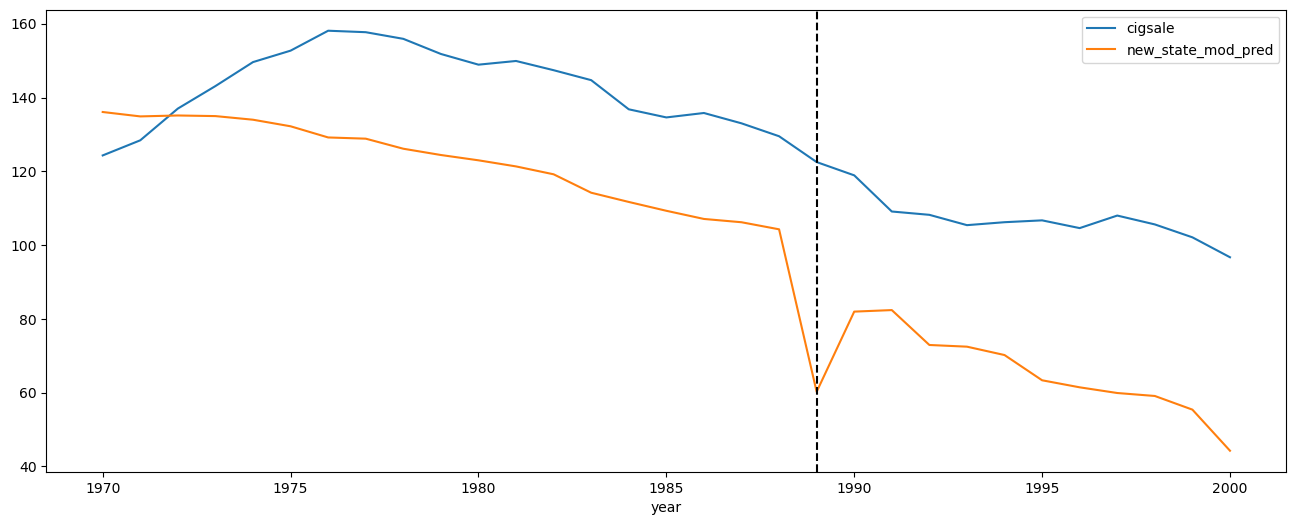

In [27]:
df_new.set_index("year")[['cigsale', 'new_state_mod_pred']].plot()
plt.axvline(x = 1989, color = "black", linestyle = "--")

As you can see, the model is basically entirely incorrect in its prediction. 

The predictions are obvious overfit to the specific example in california and hence isn't very generalisable to other scenarios (the difference between internal vs external validity). 

So to get a true causal effect we're going to need a bit more robust approach. 

We will return to this exactly example when we look at difference-in-differences (DiD).